# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
**Diagnóstico:**

*users*
- `city`: 469 nulos (11.7%), además de 96 valores "?" que también representan datos faltantes. Al estar entre 5% y 30%, se investiga: no se puede imputar la ciudad de forma confiable, así que se dejan como nulos (reemplazando "?" por NA).
- `churn_date`: 3,534 nulos (88.4%). Aunque supera el 80%, no se elimina: el nulo significa que el cliente sigue activo (no se ha dado de baja), por lo que es información válida y se deja como nulo.

*usage*
- `date`: 50 nulos (0.13%). Es menos del 5% y no afecta el análisis; se dejan como nulos.
- `duration`: 22,076 nulos (55.2%) y `length`: 17,896 nulos (44.7%). Son nulos estructurales: las llamadas no tienen longitud y los mensajes no tienen duración. Se dejan como nulos (se confirma en el paso 3.2).

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` va de 10000 a 13999 con 4,000 registros, sin valores fuera de lugar. Es un identificador, por lo que su media o desviación no tienen significado para el negocio. 
- La columna `age` tiene un mínimo de **-999**, una edad imposible: es un **sentinel** que representa un dato faltante. Este valor distorsiona las estadísticas: la media (33.7) queda muy por debajo de la mediana (47) y la desviación estándar es enorme (123), cuando en edades reales debería ser mucho menor. El máximo (79) sí es lógico. Se corregirá en el paso 3.1 reemplazando -999 por la mediana.

In [13]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no presentan valores inválidos. `id` va de 1 a 40,000 (un registro por fila) y `user_id` va de 10000 a 13999, el mismo rango que en `users`, así que todos los registros de uso corresponden a clientes existentes. 
- Las columnas `duration` y `length` no tienen sentinels: no hay valores negativos ni códigos como -999. Ambas tienen un mínimo de 0, que puede ser legítimo (llamadas no contestadas o mensajes vacíos). Lo que sí se observa son valores máximos muy alejados del resto: en `duration` el 75% de las llamadas dura menos de 7 minutos, pero el máximo es 120; en `length` el 75% de los mensajes tiene menos de 64 caracteres, pero el máximo es 1,490. Además, en ambas la media es mayor que la mediana (5.2 vs 3.5 y 52.1 vs 50), lo que indica una distribución sesgada a la derecha. Estos valores extremos no son sentinels sino posibles outliers, y se analizarán en el paso 5.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- {col} ---")
    print(users[col].value_counts(dropna=False))
    print()

--- city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` tiene 6 ciudades válidas: 3 de Colombia (Bogotá, Medellín, Cali) y 3 de México (CDMX, GDL, MTY). Las ciudades mexicanas aparecen abreviadas y las colombianas con nombre completo, pero cada ciudad usa siempre la misma forma, así que no hay duplicados por escritura. Se encontró el sentinel **"?"** en 96 filas, que representa un dato faltante. Sumado a los 469 nulos, son 565 usuarios sin ciudad (14.1% del total). Acción: reemplazar "?" por `pd.NA` en el paso 3.1.
- La columna `plan` solo tiene dos valores, `Basico` (2,595 usuarios, 64.9%) y `Premium` (1,405 usuarios, 35.1%), que coinciden con los planes de `plans.csv`. No hay valores inválidos ni nulos.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` solo tiene dos valores válidos: `text` (22,092 registros, 55.2%) y `call` (17,908 registros, 44.8%). No hay valores inválidos ni nulos.
- Al comparar con la 2.1 aparece un detalle: hay 17,924 valores en `duration` pero solo 17,908 llamadas, y 22,104 valores en `length` pero solo 22,092 mensajes. Es decir, hay al menos 16 mensajes con duración y 12 llamadas con longitud, lo cual no tiene lógica. Son muy pocos casos (menos del 0.1%), pero se revisarán en el paso 3.2.



✍️ **Comentario**

**Valores inválidos o sentinels**

- `age` (users): contiene el sentinel **-999**, una edad imposible que distorsiona la media (33.7 vs mediana 47) y la desviación estándar (123). **Acción:** reemplazarlo por la mediana, porque no se ve afectada por valores extremos.
- `city` (users): contiene el sentinel **"?"** en 96 filas. **Acción:** reemplazarlo por `pd.NA` para que se trate como dato faltante junto con los 469 nulos (565 en total, 14.1%). No se imputa porque no hay forma confiable de deducir la ciudad.
- `duration` y `length` (usage): no tienen sentinels. Los mínimos en 0 son lógicos y los máximos altos (120 min y 1,490 caracteres) son posibles outliers que se analizarán en el paso 5. Se detectaron unos pocos registros con datos que no corresponden a su tipo (16 mensajes con duración y 12 llamadas con longitud), que se revisarán en el paso 3.2.
- `user_id`, `id`, `plan` y `type`: sin valores inválidos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, los registros se distribuyen de forma muy pareja entre 2022 (1,314), 2023 (1,316) y 2024 (1,330), lo cual es coherente con un ritmo constante de nuevos clientes. Sin embargo, aparecen **40 registros con año 2026** (1% del total), una fecha imposible porque los datos solo llegan hasta 2024. Son errores de captura. No hubo fechas que no se pudieran convertir: la suma de los años da 4,000, igual al total de usuarios. **Acción:** marcar esas 40 fechas como nulas en el paso 3.1.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date`, todos los registros de uso son del año **2024** (39,950 registros). No hay años imposibles. La suma más los 50 nulos detectados en la 2.1 da los 40,000 registros totales, por lo que ninguna fecha falló al convertirse. Los 50 nulos representan solo el 0.13% y se dejan como están.
Basaremos el análisis en estas fechas.

---
✍️ **Comentario**

**Fechas fuera de rango**

- `reg_date` (users): aparecen **40 registros con año 2026**, una fecha que no había ocurrido cuando se guardaron los datos (que llegan hasta 2024). Representan el 1% de los usuarios. No hay años demasiado antiguos: el más viejo es 2022. **Acción:** marcar esas 40 fechas como nulas (`pd.NaT`), conservando el resto de la información de esos usuarios.
- `date` (usage): todas las fechas son de 2024, sin años imposibles. Solo hay 50 nulos (0.13%), que se dejan como están porque no afectan el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)
users['age'] = users['age'].astype(int)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage[usage['duration'].isna()]['type'].value_counts()

text    22076
Name: type, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage[usage['length'].isna()]['type'].value_counts()

call    17896
Name: type, dtype: int64

**Diagnóstico de nulos en `duration` y `length`**

Los nulos en ambas columnas son **MAR (Missing At Random)**, porque dependen completamente de la columna `type`:
- Los 22,076 nulos de `duration` corresponden en su totalidad a mensajes (`text`): un mensaje no tiene duración.
- Los 17,896 nulos de `length` corresponden en su totalidad a llamadas (`call`): una llamada no tiene longitud en caracteres.

**Decisión:** se dejan como nulos. No son datos perdidos sino nulos estructurales: la información no aplica para ese tipo de registro. Imputarlos (por ejemplo, con la media) sería un error, porque se estaría inventando una duración para mensajes y una longitud para llamadas.

Como observación adicional, existen 16 mensajes que sí tienen duración y 12 llamadas que sí tienen longitud (diferencia entre el total de cada tipo y sus nulos). Son menos del 0.1% de los registros y no afectan el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [28]:
# usuarios sin registros de uso
user_profile['cant_mensajes'].isna().sum()

1

In [29]:
# Rellenar con 0 al usuario sin registros de uso
columnas_uso = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_uso] = user_profile[columnas_uso].fillna(0)

# Verificar cambios
user_profile[columnas_uso].isna().sum()

cant_mensajes           0
cant_llamadas           0
cant_minutos_llamada    0
dtype: int64

Tras el `merge`, 1 usuario no tiene registros en `usage`, por lo que sus columnas de uso quedaron como nulas. Se rellenan con 0, ya que no tener registros significa que no envió mensajes ni hizo llamadas. Esto evita además que sea clasificado de forma incorrecta en la segmentación por uso.

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [31]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

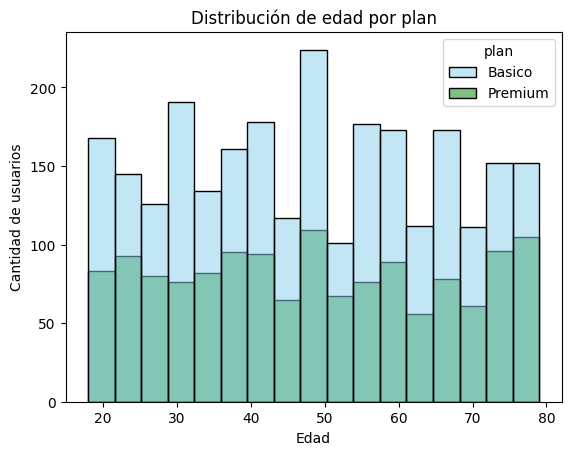

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución **aproximadamente uniforme**: hay una cantidad similar de usuarios en todas las edades entre 18 y 79 años, sin sesgo hacia ningún lado (la media y la mediana coinciden en 48).
- La barra más alta, alrededor de los 48 años, es en parte **artificial**: ahí quedaron los usuarios a los que se les asignó la mediana (48) al reemplazar el sentinel -999.
- En todos los rangos de edad hay más usuarios en el plan Básico que en el Premium, de acuerdo con su mayor participación (65% vs 35%). No se observa un grupo de edad que prefiera claramente el plan Premium.

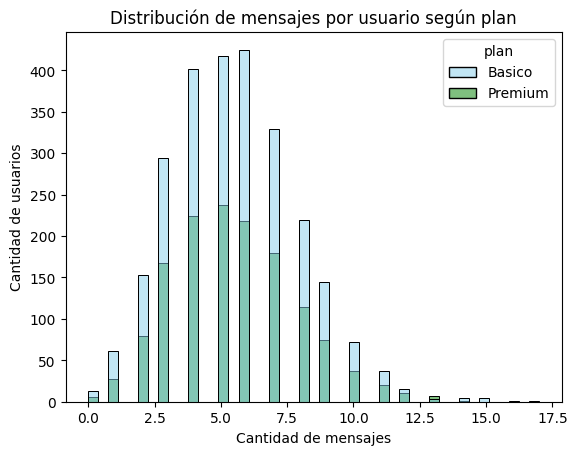

In [33]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de mensajes por usuario según plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: 
- Distribución **ligeramente sesgada a la derecha**: la mayoría de los usuarios envió entre 3 y 7 mensajes en el año, con el pico en 4–6. Pocos usuarios superan los 10 mensajes y hay casos aislados de hasta 17, que se revisarán como posibles outliers en el paso 5.2.
- Los usuarios Básico y Premium tienen **el mismo patrón**: la forma de la distribución es igual en ambos planes, solo cambia la cantidad de usuarios. Es decir, los clientes Premium no envían más mensajes que los Básico.
- El uso es muy bajo frente a lo que incluyen los planes: el plan Básico ofrece 100 mensajes y el Premium 500, pero casi nadie supera los 12.

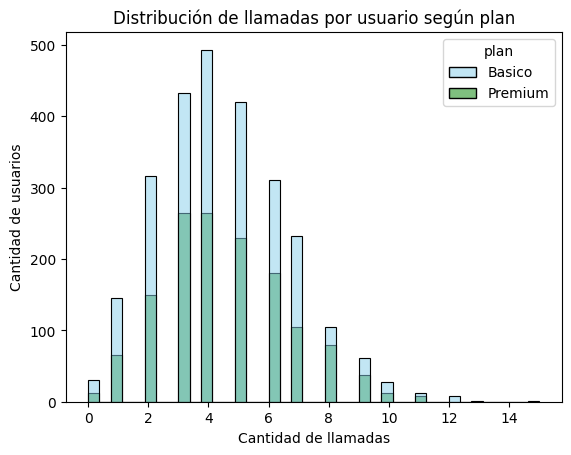

In [34]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de llamadas por usuario según plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights:
- Distribución **sesgada a la derecha**: la mayoría de los usuarios hizo entre 2 y 6 llamadas en el año, con el pico en 3–5. A partir de 10 llamadas los casos son muy pocos, y hay usuarios aislados con hasta 15, posibles outliers que se revisarán en el paso 5.2.
- Al igual que en los mensajes, los planes Básico y Premium muestran **el mismo patrón de uso**: los clientes Premium no hacen más llamadas que los Básico.
- El volumen de llamadas es bajo: la mediana es de 4 llamadas por usuario en todo el año.

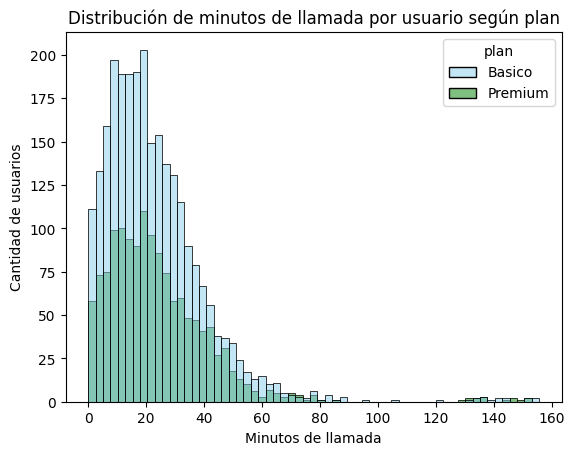

In [35]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de minutos de llamada por usuario según plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights:
- Distribución **fuertemente sesgada a la derecha**: la mayoría de los usuarios habló entre 5 y 35 minutos en todo el año, con el pico alrededor de los 10–20 minutos. A partir de 60 minutos los casos son cada vez más escasos.
- Aparece un **grupo aislado entre 130 y 155 minutos**, separado del resto de usuarios por un vacío entre 100 y 125 minutos. Este grupo está formado casi únicamente por usuarios **Premium**. Son posibles outliers que se revisarán en el paso 5.2, pero su concentración en un solo plan sugiere un segmento real de clientes que usan mucho las llamadas, no errores de registro.
- Fuera de ese grupo, ambos planes tienen el mismo patrón de uso. Incluso el usuario con más minutos (155) está lejos de los 600 minutos que incluye el plan Premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

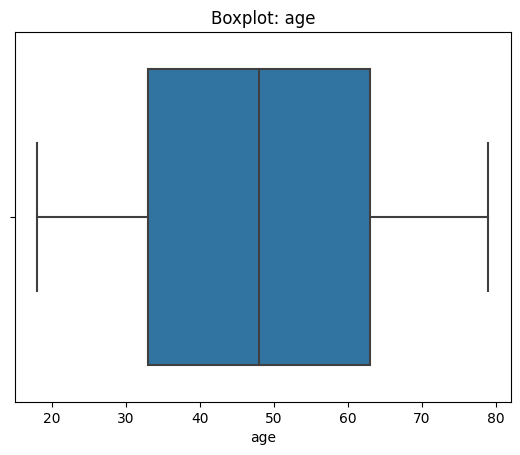

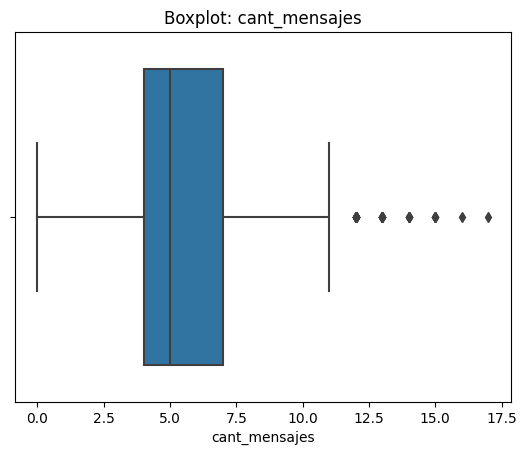

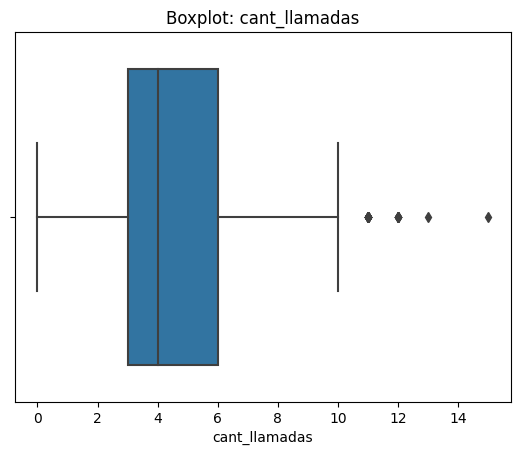

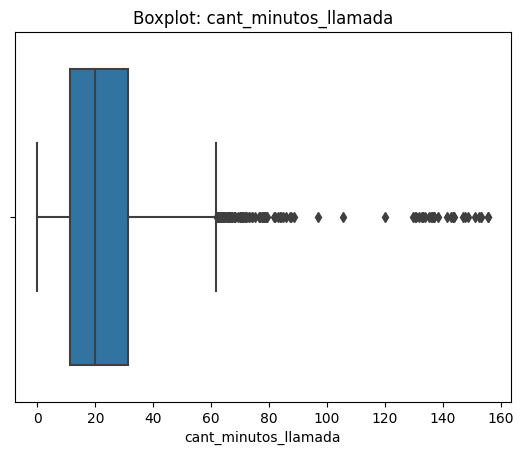

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- **age**: no presenta outliers. Todos los valores están entre 18 y 79 años, dentro de los bigotes.
- **cant_mensajes**: presenta outliers solo del lado derecho, usuarios con 12 a 17 mensajes. Son pocos y cercanos al límite.
- **cant_llamadas**: presenta outliers solo del lado derecho, usuarios con 11 a 15 llamadas. Son pocos y cercanos al límite.
- **cant_minutos_llamada**: presenta la mayor cantidad de outliers, todos del lado derecho, desde unos 62 hasta 155 minutos. Se distinguen dos grupos: uno continuo entre 62 y 90 minutos, y otro aislado entre 130 y 155 minutos (el grupo Premium detectado en el histograma).

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    cantidad = (user_profile[col] > limite_superior).sum()
    print(f"{col}: límite superior = {limite_superior:.2f}, outliers = {cantidad}")


cant_mensajes: límite superior = 11.50, outliers = 46
cant_llamadas: límite superior = 10.50, outliers = 30
cant_minutos_llamada: límite superior = 61.87, outliers = 109


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights:
- **cant_mensajes**: límite superior de 11.5 y máximo de 17; hay 46 outliers (1.2% de los usuarios). **Se mantienen**, porque enviar entre 12 y 17 mensajes al año es un comportamiento perfectamente posible, está cerca del límite y muy por debajo de los 100 mensajes que incluye el plan Básico. No hay señales de error de registro.
- **cant_llamadas**: límite superior de 10.5 y máximo de 15; hay 30 outliers (0.8%). **Se mantienen** por la misma razón: son valores realistas y cercanos al límite.
- **cant_minutos_llamada**: límite superior de 61.9 y máximo de 155.7; hay 109 outliers (2.7%). **Se mantienen**, porque representan clientes que usan intensivamente las llamadas, no errores. En particular, el grupo aislado de 130–155 minutos está formado casi solo por usuarios Premium, lo que indica un segmento real de alto consumo que es valioso para el negocio. Eliminarlos haría perder justamente la información sobre los clientes más activos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
# Crear columna grupo_uso
def clasificar_uso(fila):
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

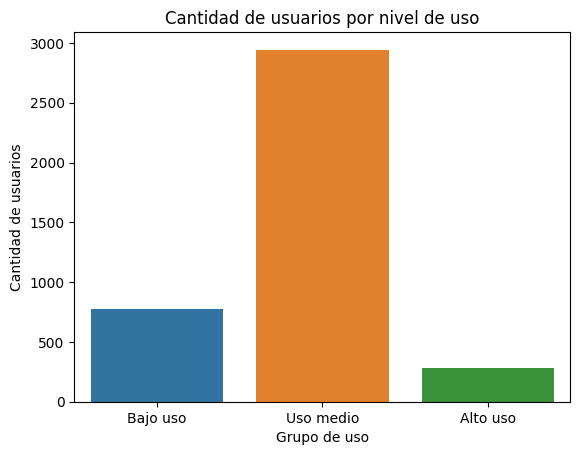

In [43]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Cantidad de usuarios por nivel de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [44]:
# Visualización de los segmentos por edad
for col in ['grupo_uso', 'grupo_edad']:
    print(f"--- {col} ---")
    print(user_profile[col].value_counts())
    print(user_profile[col].value_counts(normalize=True).round(3) * 100)
    print()

--- grupo_uso ---
Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64
Uso medio    73.6
Bajo uso     19.5
Alto uso      7.0
Name: grupo_uso, dtype: float64

--- grupo_edad ---
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64
Adulto          50.4
Adulto Mayor    30.6
Joven           19.0
Name: grupo_edad, dtype: float64



In [45]:
# Cruce de segmentos: nivel de uso según grupo de edad y según plan (en %)
print("--- Nivel de uso por grupo de edad ---")
print((pd.crosstab(user_profile['grupo_edad'], user_profile['grupo_uso'], normalize='index') * 100).round(1))
print()
print("--- Nivel de uso por plan ---")
print((pd.crosstab(user_profile['plan'], user_profile['grupo_uso'], normalize='index') * 100).round(1))

--- Nivel de uso por grupo de edad ---
grupo_uso     Alto uso  Bajo uso  Uso medio
grupo_edad                                 
Adulto             7.6      18.1       74.3
Adulto Mayor       6.1      21.0       72.9
Joven              6.7      20.7       72.6

--- Nivel de uso por plan ---
grupo_uso  Alto uso  Bajo uso  Uso medio
plan                                    
Basico          7.1      19.8       73.1
Premium         6.6      18.9       74.4



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- `age`: 55 usuarios (1.4%) tenían el sentinel -999. Se reemplazó por la mediana (48 años).
- `city`: 96 usuarios con el sentinel "?" y 469 nulos; en total 565 usuarios sin ciudad (14.1%). Se dejaron como nulos porque no es posible deducir la ciudad.
- `reg_date`: 40 usuarios (1%) con fecha de registro en 2026, imposible porque los datos llegan hasta 2024. Se marcaron como nulos.
- `date` (usage): 50 registros sin fecha (0.13%), sin impacto en el análisis.
- `duration` y `length`: más del 40% de nulos en cada una, pero son nulos estructurales (MAR): los mensajes no tienen duración y las llamadas no tienen longitud.
- 1 usuario no tenía ningún registro de uso; se le asignó 0 en mensajes, llamadas y minutos.

🔍 **Segmentos por Edad**
- La base de clientes es mayoritariamente **Adulta** (30–59 años, 50.4%), seguida de **Adulto Mayor** (60+, 30.6%) y **Joven** (menores de 30, 19.0%).
- El nivel de uso es prácticamente igual en los tres grupos: entre 72.6% y 74.3% son de uso medio, y el alto uso va de 6.1% a 7.6%. La edad **no** determina cuánto usa el cliente.

📊 **Segmentos por Nivel de Uso**
- **Uso medio**: 2,943 usuarios (73.6%). Es el comportamiento típico del cliente.
- **Bajo uso**: 779 usuarios (19.5%), con menos de 5 llamadas y 5 mensajes en todo 2024.
- **Alto uso**: 278 usuarios (7.0%). Es el segmento más pequeño.
- Los planes tampoco marcan diferencia: Básico y Premium tienen casi la misma proporción de cada nivel de uso (alto uso: 7.1% vs 6.6%).

🚩 **Patrones de uso extremo (outliers)**
- Se detectaron outliers solo del lado alto: 46 usuarios en mensajes, 30 en llamadas y 109 en minutos de llamada. Se mantuvieron porque son comportamientos posibles, no errores.
- Destaca un grupo aislado de usuarios con **130 a 155 minutos** de llamada al año, compuesto casi únicamente por clientes Premium. Es un segmento real de alto consumo de llamadas.

➡️ Esto sugiere que **el uso real está muy por debajo de lo que ofrecen los planes**. En todo 2024, el usuario promedio envió 5.5 mensajes, hizo 4.5 llamadas y habló 23 minutos, cuando el plan Básico incluye 100 mensajes y 100 minutos **al mes**, y el Premium 500 mensajes y 600 minutos. Además, los clientes Premium (35%) pagan más del doble ($25 vs $12) pero usan lo mismo que los Básico. Los clientes no están eligiendo su plan según su consumo.

💡 **Recomendaciones**
- **Crear un plan de entrada más económico**, con menos minutos y mensajes, para el 19.5% de bajo uso. Es una forma de retenerlos antes de que se vayan por pagar algo que no usan.
- **Reforzar el valor del plan Premium** con beneficios distintos al volumen de llamadas y mensajes (por ejemplo, más GB de datos o servicios adicionales), ya que hoy sus clientes no aprovechan la diferencia y están en riesgo de cambiarse al Básico o a otra compañía.
- **Diseñar una oferta específica para el grupo de alto consumo de llamadas** (130–155 minutos), que es casi todo Premium: son los clientes que más aprovechan el servicio y conviene cuidarlos.
- **Mejorar la captura de datos**: hacer obligatorio el campo de ciudad, validar la edad y no permitir fechas de registro futuras en el sistema.
- Como siguiente paso, analizar el **uso de datos móviles (GB)**, que este análisis no incluye y podría ser lo que realmente diferencia a los clientes Premium.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`